In [1]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES

results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250718-train-ablation',
    []
)
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)
round_metrics_df['dms_shortname'] = round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

Loading results for DMSs: {'SHOC2_HUMAN_Kwon_2022', 'BLAT_ECOLX_Firnberg_2014', 'OXDA_RHOTO_Vanella_2023_activity', 'HSP82_YEAST_Flynn_2019', 'ANCSZ_Hobbs_2022', 'HEM3_HUMAN_Loggerenberg_2023', 'PPM1D_HUMAN_Miller_2022', 'CBS_HUMAN_Sun_2020', 'HXK4_HUMAN_Gersing_2022_activity'}


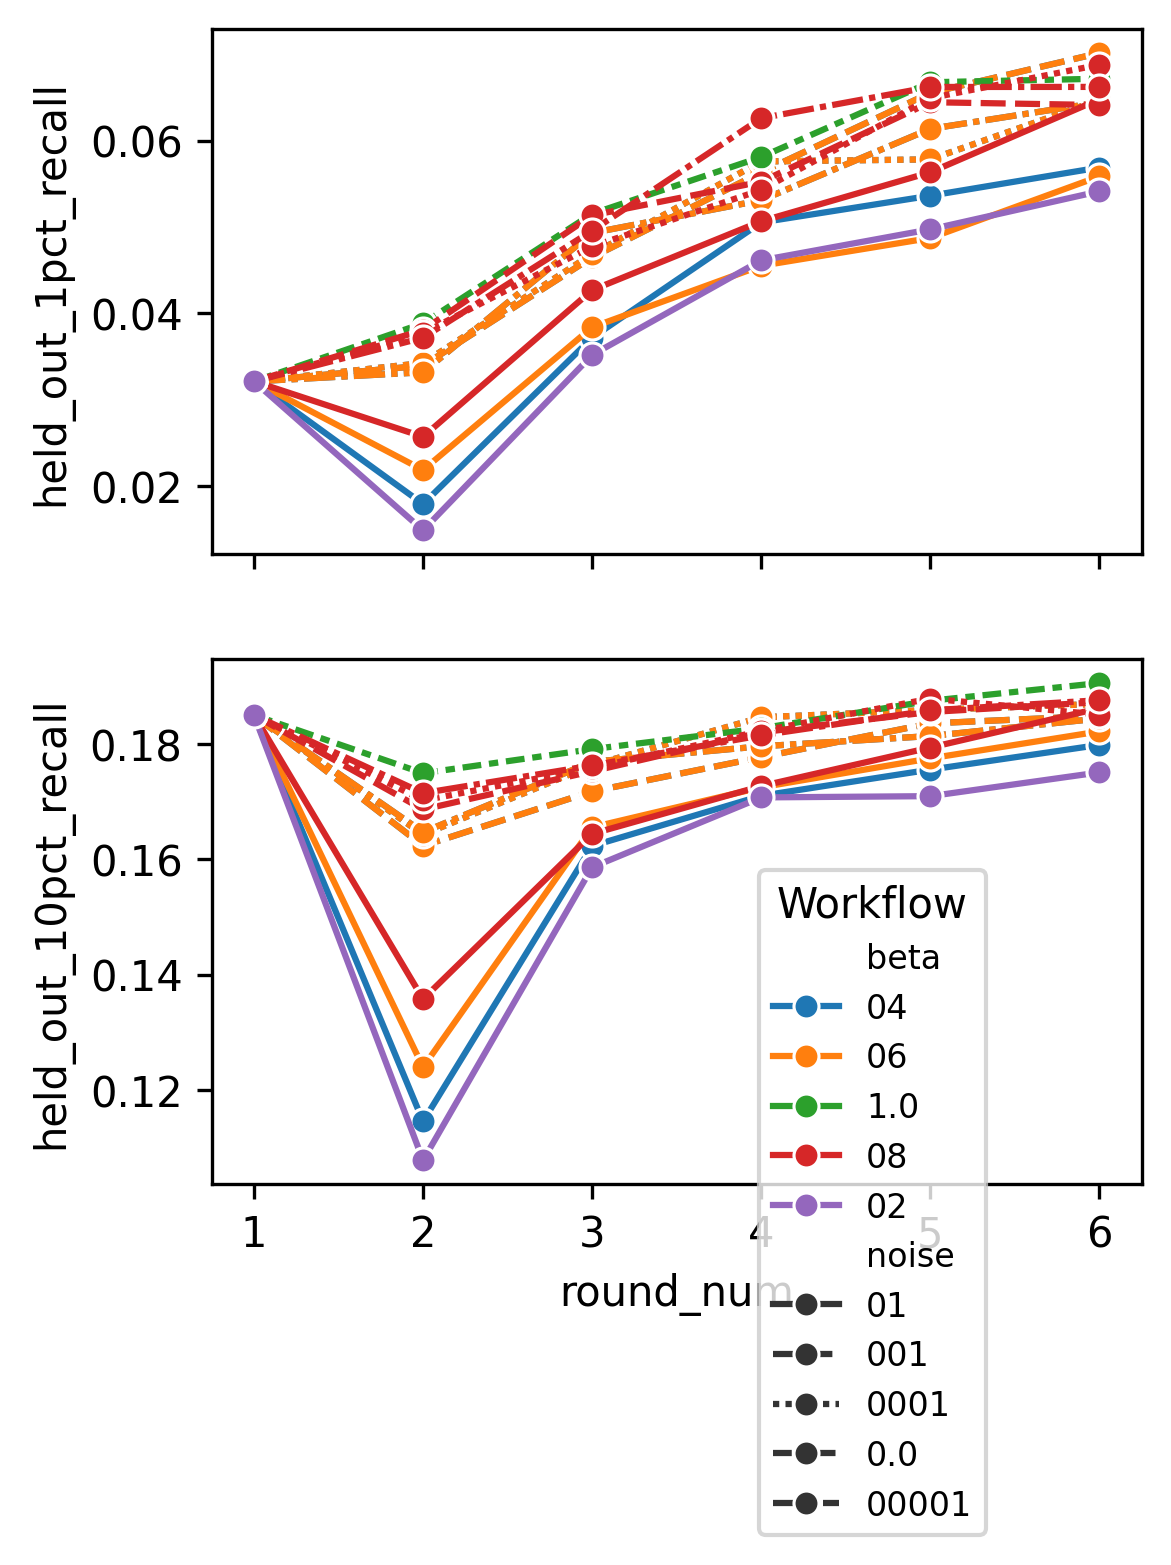

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import re

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 5), sharex=True, dpi=300)

CONFIGS = [c for c in round_metrics_df.config_name.unique() if ('base' in c or '-sp-' in c)]# or 'no-naturalnessTraining' in c)]
plot_df = round_metrics_df[round_metrics_df.config_name.isin(CONFIGS)].copy()
def get_sp_params(config_name):
    m = re.match(r'FolDE-with-sp-(\d+)-(\d+)', config_name)
    if not m:
        return 1.0, 0.0
    return m.groups()[0], m.groups()[1]
plot_df['beta'] = plot_df.config_name.apply(lambda x: get_sp_params(x)[0])
plot_df['noise'] = plot_df.config_name.apply(lambda x: get_sp_params(x)[1])

for ax, metric in zip([ax1, ax2], ['held_out_1pct_recall', 'held_out_10pct_recall']):
    sns.lineplot(
        ax=ax,
        data=plot_df,
        # y='held_out_activity_spearman',
        y=metric,
        # y='held_out_1pct_auc',
        # y='held_out_activity_spearman',
        x='round_num',
        hue='beta',
        errorbar=None,
        marker='o',
        style='noise'
        # style='config_name',
        # errorbar=None
    )

# Disable ax1 legend
ax1.get_legend().remove()
ax2.legend(
    title='Workflow',
    loc='lower right',
    bbox_to_anchor=(0.85, -0.7),
    fontsize=8
)
